### Example 3

In [1]:
### Bayesian test for correlation with ZDJ prior

### General imports
import pandas as pd
import xarray as xr
import re
import numpy as np
import urllib.request

### Plots
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
### Color list 
dark_oranges = sns.color_palette("Oranges", n_colors=15)[4:]
dark_purples = sns.color_palette("Purples", n_colors=9)[4:]
dark_greens = sns.color_palette("Greens", n_colors=9)[4:]
TITLE_FONTSIZE = 12
LABEL_FONTSIZE = 10
LEGEND_FONTSIZE = 10
TICK_FONTSIZE = 9
ANNOT_FONTSIZE = 8

#Stats
from scipy.special import gamma
from scipy.integrate import quad
from scipy.stats import f
from scipy.stats import pearsonr


In [2]:
# URL of the data file
url = "https://crudata.uea.ac.uk/cru/data/temperature/HadCRUT5.0Analysis_gl.txt"

# Fetch the data from the URL
with urllib.request.urlopen(url) as response:
    lines = response.read().decode('utf-8').splitlines()

# Parse the lines to extract the data
data = []
months = []
years = []
for line in lines[::2]:
    values = line.split(' ')[2:-1]
    years.append(line.split(' ')[0])
    years.append(line.split(' ')[1])
    for i, value in enumerate(values):
        if value != '':
            data.append(value)
            months.append(i)

# Convert the list of lists into a NumPy array
data_array = np.array(data, dtype=float)
data_array = data_array

# Print the resulting NumPy array
print(data_array)

time = pd.date_range(start='1850-01-01', end='2025-12-01', freq='MS')
HadCRUT5 = xr.DataArray(
    data_array[:], 
    coords={'time': time}, 
    dims='time', 
    name='temperature - HadCRU5'
)

HadCRUT5_annual = HadCRUT5.groupby('time.year').mean(dim='time')

# Anomaly relative to 1951–1980
HadCRUT5_annual_anom = HadCRUT5_annual - HadCRUT5_annual.sel(year=slice('1961','1990')).mean(dim='year')

# --- Prep data assumed available: ds with 'year' and 'GMST' ---
t = np.asarray(HadCRUT5_annual_anom['year'].values).astype(float)
y = HadCRUT5_annual_anom.values.astype(float)

[-0.734 -0.36  -0.627 ... -9.999 -9.999 -9.999]


In [3]:
# Focus period (as in your code)
mask_short = (t >= 1950) & (t <= 2022)
t_short = t[mask_short]
y_short = y[mask_short]
n = len(y_short)

# =========================
# Linear model (full period)
# =========================
X_lin = np.column_stack([np.ones(n), t_short])
beta_lin, *_ = np.linalg.lstsq(X_lin, y_short, rcond=None)
yhat_lin = X_lin @ beta_lin
resid_lin = y_short - yhat_lin

# =========================
# ENSO (ONI) loading & annual mean
# =========================
oni_path = '/home/jmindlin/BF_codes/data/oni_data.txt'

def load_oni_xarray(src):
    # Adjust reading logic to your file; this mirrors your approach.
    df_oni = np.loadtxt(src, skiprows=1, max_rows=76)
    oni = np.concatenate([df_oni[i, 1:13].flatten() for i in range(df_oni.shape[0]-1)])
    t_monthly = pd.date_range('1950-01-01', '2025-01-01', freq='ME')
    da = xr.DataArray(
        oni, dims=["time"], coords={"time": t_monthly}, name="oni",
        attrs={"units": "degC", "source": "NOAA"}
    )
    return da

oni = load_oni_xarray(oni_path)
oni_annual = oni.groupby('time.year').mean(dim='time')  # annual mean 1950–2024
oni_years = oni_annual['year'].values.astype(int)

oni_vals = (oni_annual - oni_annual.sel(year=slice('1961','1990')).mean(dim='year')).values

# =========================
# Quadratic detrending (1950–2024)
# =========================
X_quad = np.column_stack([np.ones(len(t_short)), t_short, t_short**2])
beta_quad, *_ = np.linalg.lstsq(X_quad, y_short, rcond=None)
yhat_quad_shortPeriod = X_quad @ beta_quad
resid_quad_shortPeriod = y_short - yhat_quad_shortPeriod

# =========================
# Align ONI to years of GMST residuals
# =========================
t_enso_years = t_short.astype(int)
oni_map = {int(yy): float(val) for yy, val in zip(oni_years, oni_vals)}
oni_aligned = np.array([oni_map.get(int(yy), np.nan) for yy in t_enso_years], dtype=float)

valid = ~np.isnan(oni_aligned)
t_enso = t_short[valid]
y_enso = resid_quad_shortPeriod[valid]
oni_aligned = oni_aligned[valid]
n = len(y_enso)

# =========================
# Quadratic detrending (1950–2024)
# =========================
X_quad = np.column_stack([np.ones(len(t_enso)), t_enso, t_enso**2])
beta_quad, *_ = np.linalg.lstsq(X_quad, y_enso, rcond=None)
yhat_quad_shortPeriod = X_quad @ beta_quad
resid_quad_shortPeriod = y_short - yhat_quad_shortPeriod

# =========================
# Diagnostics / statistics
# =========================
# Pearson correlation and p-value (two-sided)
from scipy.stats import pearsonr, t as student_t
r, p = pearsonr(y_enso, oni_aligned)

# R^2 from simple regression of residuals on ONI
X_enso = np.column_stack([np.ones(n), oni_aligned])
# beta_enso, *_ = np.linalg.lstsq(X_enso, y_enso, rcond=None)
beta_enso, *_ = np.linalg.lstsq(X_enso, y_enso, rcond=None) 
yhat_enso = X_enso @ beta_enso
resid_enso = y_enso - yhat_enso
RSS_enso = np.sum(resid_enso**2)
TSS_enso = np.sum((y_enso - np.mean(y_enso))**2)
R2_enso = 1 - RSS_enso / TSS_enso

# JZS Bayes factor for k=1 predictor using the Wetzels & Wagenmakers setup

def bayes_factor_JZS(n, k, R2):
    """
    JZS Bayes factor for linear regression with k predictors (excluding intercept).
    Mirrors the 1D integral used in Wetzels & Wagenmakers (2012).
    """
    def integrand(g):
        return (1 + g)**((n - k - 1) / 2) * (1 + (1 - R2) * g)**(-(n - 1) / 2) * g**(-3 / 2) * np.exp(-n / (2 * g))
    integral, _ = quad(integrand, 0, np.inf, limit=200)
    # Prefactor; reduces to a simple function of n when k=1
    BF = ((n / 2)**(k / 2) * gamma((k + 1) / 2)) / (np.sqrt(np.pi) * gamma(k / 2)) * integral
    return BF

BF10 = bayes_factor_JZS(n=n, k=1, R2=R2_enso)
BF01 = 1.0 / BF10

# =========================
# Regression coefficient
# ========================
slope_enso = beta_enso[1]
intercept_enso = beta_enso[0]



In [4]:
# === Load Tmin and Tmax ===
tmin = xr.open_dataset("/climca/data/OBS/CPC/cpc_data/tmax_1979_2024_mon.nc")['tmax']
tmax = xr.open_dataset("/climca/data/OBS/CPC/cpc_data/tmin_1979_2024_mon.nc")['tmin']

# === Compute Tmean ===
tmean = (tmin + tmax) / 2
tmean.name = "tmean"
tmean.attrs['units'] = tmin.attrs.get('units', 'degC')
tmean.attrs['long_name'] = "Monthly Mean Temperature"

pr = xr.open_dataset("/climca/data/OBS/CPC/cpc_data/precip_1979_2024_mon.nc")['precip']

In [5]:
### Compute correlation between tmean and ONI for Sep-Nov, use oni (no annual mean
# Select Sep-Nov months
tmean_son = tmean.sel(time=tmean['time.month'].isin([10, 11, 12]))
pr_son = pr.sel(time=pr['time.month'].isin([10, 11, 12]))
oni_son = oni.sel(time=oni['time.month'].isin([10, 11, 12]))
# Group by year and compute mean
tmean_son_annual = tmean_son.groupby('time.year').mean(dim='time')
oni_son_annual = oni.groupby('time.year').mean(dim='time').sel(year=slice('1979','2024'))
pr_son_annual = pr_son.groupby('time.year').mean(dim='time')
# Align years with ONI
tmean_years = tmean_son_annual['year'].values.astype(int)

In [6]:
pr_sesa = pr_son_annual.sel(lat=slice(-25, -35), lon=slice(300, 310)).mean(dim={'lat','lon'})

# Range of correlation values for curves
rs = np.linspace(-0.99, 0.99, 200)

# Different sample sizes to illustrate sensitivity
ns = [10, 20, 30, 50, 100]

### Compute correlation and repeat Bayesian test done with GMST but for pr_sesa
# Extract values for correlation
pr_vals = pr_sesa.values
oni_vals_son = oni_son_annual.values
# Ensure same length and align
valid = ~np.isnan(pr_vals) & ~np.isnan(oni_vals_son)
pr_vals_valid = pr_vals[valid]
oni_vals_valid = oni_vals_son[valid]
n_pr = len(pr_vals_valid)
# Pearson correlation and p-value
r_pr, p_pr = pearsonr(pr_vals_valid, oni_vals_valid)
# R^2 for regression of pr on ONI
X_pr = np.column_stack([np.ones(n_pr), oni_vals_valid])
beta_pr, *_ = np.linalg.lstsq(X_pr, pr_vals_valid, rcond=None)
yhat_pr = X_pr @ beta_pr
resid_pr = pr_vals_valid - yhat_pr
RSS_pr = np.sum(resid_pr**2)
TSS_pr = np.sum((pr_vals_valid - np.mean(pr_vals_valid))**2)
R2_pr = 1 - RSS_pr / TSS_pr
# JZS Bayes factor for pr vs ONI
BF10_pr = bayes_factor_JZS(n=n_pr, k=1, R2=R2_pr)
BF01_pr = 1.0 / BF10_pr
# Print results
print(f"Precipitation vs ONI (SON, 1979-2024):")
print(f"Pearson r = {r_pr:.3f}, p-value = {p_pr:.3g}")
print(f"R^2 = {R2_pr:.3f}")
print(f"BF10 (JZS) = {BF10_pr:.3g}, BF01 = {BF01_pr:.3g}")

Precipitation vs ONI (SON, 1979-2024):
Pearson r = 0.675, p-value = 2.69e-07
R^2 = 0.455
BF10 (JZS) = 3.23e+04, BF01 = 3.09e-05


/tmp/ipykernel_374235/2558245148.py:46: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  axs[0].text(


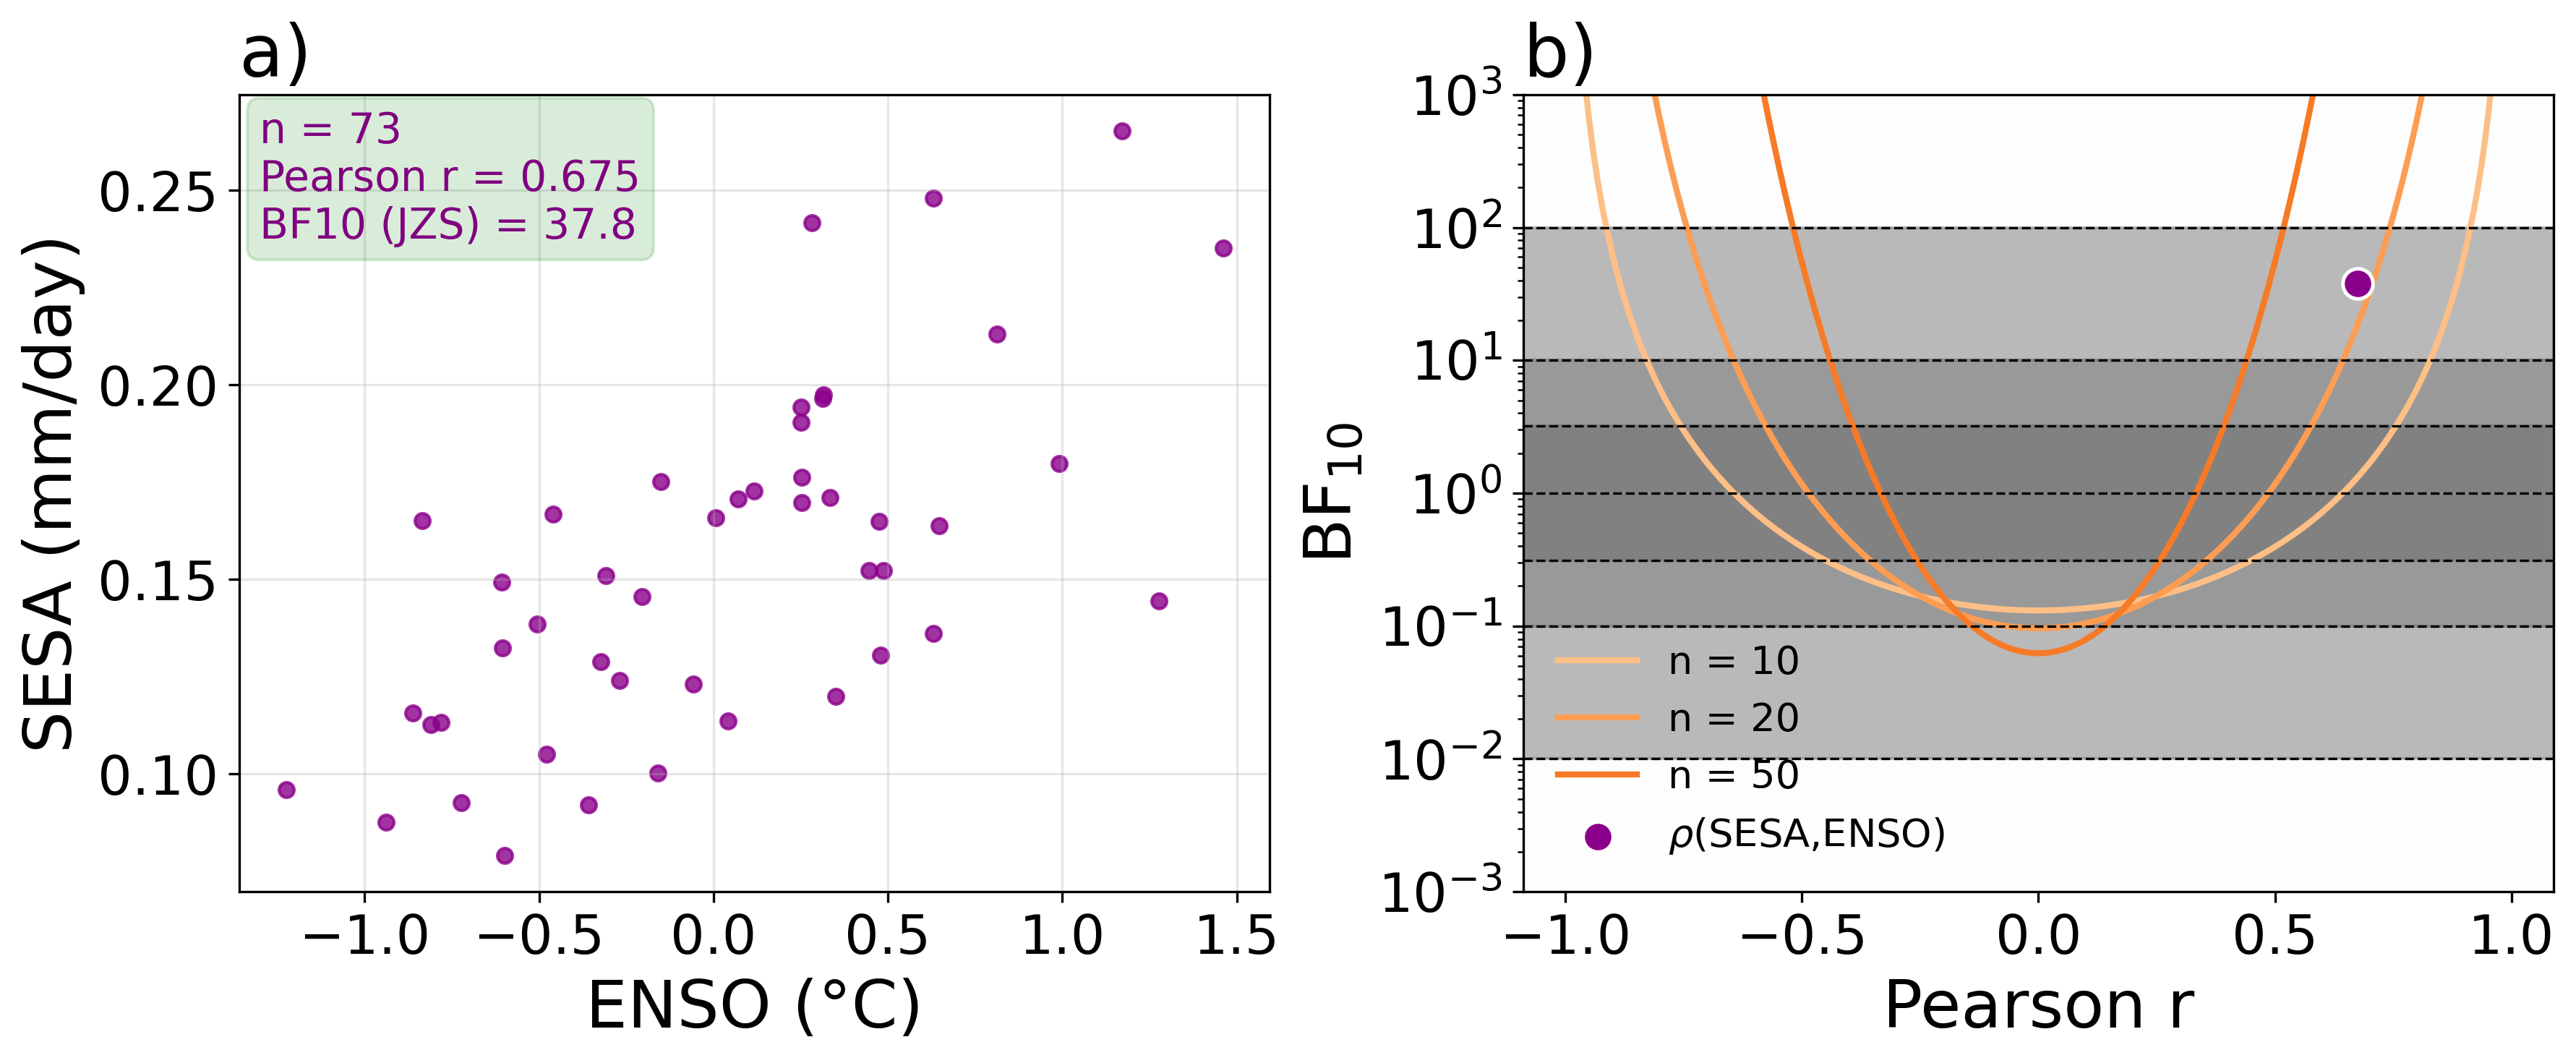

In [7]:
# === DATA ===
### Compute correlation and repeat Bayesian test done with GMST but for pr_sesa
# Extract values for correlation
pr_vals = pr_sesa.values
oni_vals_son = oni_son_annual.values
# Ensure same length and align
valid = ~np.isnan(pr_vals) & ~np.isnan(oni_vals_son)
pr_vals_valid = pr_vals[valid]
oni_vals_valid = oni_vals_son[valid]
n_pr = len(pr_vals_valid)
# Pearson correlation and p-value
r_pr, p_pr = pearsonr(pr_vals_valid, oni_vals_valid)
# ========

# === FONT SETTINGS ===
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 18
LEGEND_FONTSIZE = 13
ANNOT_FONTSIZE = 14

# === Data and setup ===
ns = [10, 20, 50]
rs = np.linspace(-0.99, 0.99, 200)

# Example annotation text
txt = (
    f"n = {n}\n"
    f"Pearson r = {r_pr:.3f}\n"
    f"BF10 (JZS) = {BF10:.3g}"
)

# === Figure ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# === Panel (a): Scatter plot ===
axs[0].scatter(oni_vals_valid, pr_vals_valid/30, alpha=0.8, s=25,
               color='darkmagenta', label='Data points')
axs[0].set_xlabel('ENSO (°C)', fontsize=LABEL_FONTSIZE)
axs[0].set_ylabel('SESA (mm/day)', fontsize=LABEL_FONTSIZE)
axs[0].set_title('a) ', loc='left',fontsize=TITLE_FONTSIZE)
axs[0].tick_params(axis='both', labelsize=TICK_FONTSIZE)
axs[0].grid(alpha=0.3)

# Annotation box (top-left)
axs[0].text(
    0.02, 0.98, txt,
    transform=axs[0].transAxes,
    va='top', ha='left',
    fontsize=ANNOT_FONTSIZE,
    color='purple',
    bbox=dict(boxstyle="round", alpha=0.15, color='green', edgecolor='none')
)


from matplotlib.ticker import LogLocator, LogFormatterMathtext

# ======================
# Panel (b): JZS Bayes Factor curves
# ======================

# --- Symmetric shading ---
regions = [
    (1, 3.2, 0.99),   # negligible
    (3.2, 10, 0.8),  # substantial
    (10, 100, 0.55),  # strong
    (100, 1000, 0.01) # decisive
]

# Upper (BF > 1)
for y0, y1, alpha in regions:
    axs[1].axhspan(y0, y1, color='gray', alpha=alpha, zorder=0)

# Lower (BF < 1) mirrored
for y0, y1, alpha in regions:
    axs[1].axhspan(1/y1, 1/y0, color='gray', alpha=alpha, zorder=0)

# --- Plot curves ---
for i, n_val in enumerate(ns):
    BF_vals = [bayes_factor_JZS(n=n_val, k=1, R2=r_val**2) for r_val in rs]
    axs[1].plot(rs, BF_vals, color=dark_oranges[i*2], label=f'n = {n_val}', lw=2)

# --- Threshold lines (both sides) ---
thresholds = [1, 3.2, 10, 100]
for t in thresholds:
    axs[1].axhline(t, color='black', linestyle='--', linewidth=0.8, zorder=2)
    if t != 1:
        axs[1].axhline(1/t, color='black', linestyle='--', linewidth=0.8, zorder=2)

# --- Highlight observed point ---
axs[1].scatter(
    r_pr, BF10,
    color='darkmagenta',
    s=100,
    edgecolor='white',
    linewidth=1.2,
    zorder=5,
    label=r'$\rho$(SESA,ENSO)'
)

# --- Axes formatting ---
axs[1].set_yscale('log')
axs[1].set_ylim(1/1000, 1000)

# Proper log ticks
axs[1].yaxis.set_major_locator(LogLocator(base=10))
axs[1].yaxis.set_major_formatter(LogFormatterMathtext(base=10))
axs[1].yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))
axs[1].yaxis.set_minor_formatter(lambda *args: "")

axs[1].set_xlabel('Pearson r', fontsize=LABEL_FONTSIZE)
axs[1].set_ylabel(r'BF$_{10}$', fontsize=LABEL_FONTSIZE)
axs[1].set_title('b) ', loc='left', fontsize=TITLE_FONTSIZE)

axs[1].tick_params(axis='both', labelsize=TICK_FONTSIZE)
axs[1].legend(fontsize=LEGEND_FONTSIZE, frameon=False,loc='lower left')

# Grid on top of shading
axs[1].grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()

In [19]:
# assume you already have: tmean_son_annual (with dim 'year' + spatial dims)
# and oni_son_annual (1D DataArray with dim 'year')
# and a function bayes_factor_JZS(n, k, R2)
def compute_correlation_bf_p(y, x):
    """
    y, x: 1D arrays along 'year'
    returns: (r, BF10, p)
    """
    # handle NaNs
    mask = np.isfinite(y) & np.isfinite(x)
    y_ = y[mask]
    x_ = x[mask]

    # not enough data → NaNs
    if y_.size < 3:
        return np.nan, np.nan, np.nan

    r, p = pearsonr(y_, x_)
    R2 = r**2
    n = y_.size

    BF10 = bayes_factor_JZS(n=n, k=1, R2=R2)
    return r, BF10, p

def effective_sample_size(y, x):
    """
    Estimate effective sample size using lag-1 autocorrelation
    of both time series.
    """
    def lag1_autocorr(a):
        if len(a) < 3:
            return np.nan
        return np.corrcoef(a[:-1], a[1:])[0, 1]

    rho_y = lag1_autocorr(y)
    rho_x = lag1_autocorr(x)

    if not np.isfinite(rho_y) or not np.isfinite(rho_x):
        return len(y)

    rho = np.sqrt(rho_y * rho_x)

    n = len(y)
    n_eff = n * (1 - rho) / (1 + rho)

    return max(3, n_eff)  # avoid degenerate cases

### Effective sample size test (not implemented yet)
# def compute_correlation_bf_p(y, x):
#     """
#     Same as before, but with effective sample size for BF
#     """

#     # handle NaNs
#     mask = np.isfinite(y) & np.isfinite(x)
#     y_ = np.asarray(y)[mask]
#     x_ = np.asarray(x)[mask]

#     if y_.size < 3:
#         return np.nan, np.nan, np.nan

#     n = y_.size
#     t = np.arange(n)

#     # --- detrend ---
#     coef_y = np.polyfit(t, y_, 1)
#     y_d = y_ - np.polyval(coef_y, t)

#     coef_x = np.polyfit(t, x_, 1)
#     x_d = x_ - np.polyval(coef_x, t)

#     # --- standardize ---
#     y_std = y_d.std(ddof=1)
#     x_std = x_d.std(ddof=1)

#     if y_std == 0 or x_std == 0 or not np.isfinite(y_std) or not np.isfinite(x_std):
#         return np.nan, np.nan, np.nan

#     y_z = (y_d - y_d.mean()) / y_std
#     x_z = (x_d - x_d.mean()) / x_std

#     # correlation & p-value (unchanged)
#     r, p = pearsonr(y_z, x_z)
#     R2 = r**2

#     # NEW: effective sample size
#     n_eff = effective_sample_size(y_z, x_z)

#     # use n_eff in BF
#     BF10 = bayes_factor_JZS(n=n_eff, k=1, R2=R2)

#     return r, BF10, p

In [20]:
r_map_enso, bf_map_enso, p_map_enso = xr.apply_ufunc(
    compute_correlation_bf_p,
    pr_son_annual,
    oni_son_annual,
    input_core_dims=[['year'], ['year']],
    output_core_dims=[[], [], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float, float, float],
    # or instead of explicit align: join='inner'
    # join='inner',
)

r_map_enso = r_map_enso.rename("r")
bf_map_enso = bf_map_enso.rename("BF10")
p_map_enso = p_map_enso.rename("p")

In [10]:
# === Limit to South America ===
sa = dict(lon=slice(270, 330), lat=slice(14, -60))

r_sa = r_map_enso.sel(**sa)
bf_sa = bf_map_enso.sel(**sa)
p_sa = p_map_enso.sel(**sa)   # make sure you have p_map_pr from your apply_ufunc

## levels showing where bf are larger than 3
bf_levels = [3, 100]

bf_levels_no_ev = [1/3]

In [21]:
def fdr_bh_xarray(pvals, alpha=0.05, dim=None):
    """
    Apply Benjamini-Hochberg FDR correction to an xarray DataArray.

    Parameters
    ----------
    pvals : xr.DataArray
        Array of p-values (can be multi-dimensional, e.g., lat x lon)
    alpha : float
        Desired FDR level (default 0.05)
    dim : list or None
        Dimensions over which to apply FDR (default: all)

    Returns
    -------
    sig_mask : xr.DataArray (bool)
        True where significant after FDR correction
    pvals_adj : xr.DataArray
        Adjusted p-values (BH)
    """

    # stack dimensions if needed
    if dim is None:
        stacked = pvals.stack(all_dims=pvals.dims)
        dims_out = pvals.dims
    else:
        stacked = pvals.stack(all_dims=dim)
        dims_out = dim

    p = stacked.values
    mask = np.isfinite(p)

    p_clean = p[mask]
    m = len(p_clean)

    # sort p-values
    order = np.argsort(p_clean)
    p_sorted = p_clean[order]

    # BH thresholds
    ranks = np.arange(1, m + 1)
    thresholds = (ranks / m) * alpha

    # find largest significant p-value
    below = p_sorted <= thresholds
    if np.any(below):
        max_idx = np.max(np.where(below))
        cutoff = p_sorted[max_idx]
    else:
        cutoff = 0.0

    # significance mask
    sig = p <= cutoff

    # adjusted p-values (BH)
    p_adj = np.full_like(p, np.nan)
    p_adj_vals = p_sorted * m / ranks
    p_adj_vals = np.minimum.accumulate(p_adj_vals[::-1])[::-1]

    # reorder
    p_adj_clean = np.empty_like(p_clean)
    p_adj_clean[order] = p_adj_vals

    p_adj[mask] = p_adj_clean

    # back to xarray
    sig_da = xr.DataArray(sig, coords=stacked.coords, dims=stacked.dims)
    p_adj_da = xr.DataArray(p_adj, coords=stacked.coords, dims=stacked.dims)

    # unstack
    sig_da = sig_da.unstack("all_dims")
    p_adj_da = p_adj_da.unstack("all_dims")

    return sig_da, p_adj_da

In [12]:
sig_mask, p_adj = fdr_bh_xarray(p_sa, alpha=0.20)

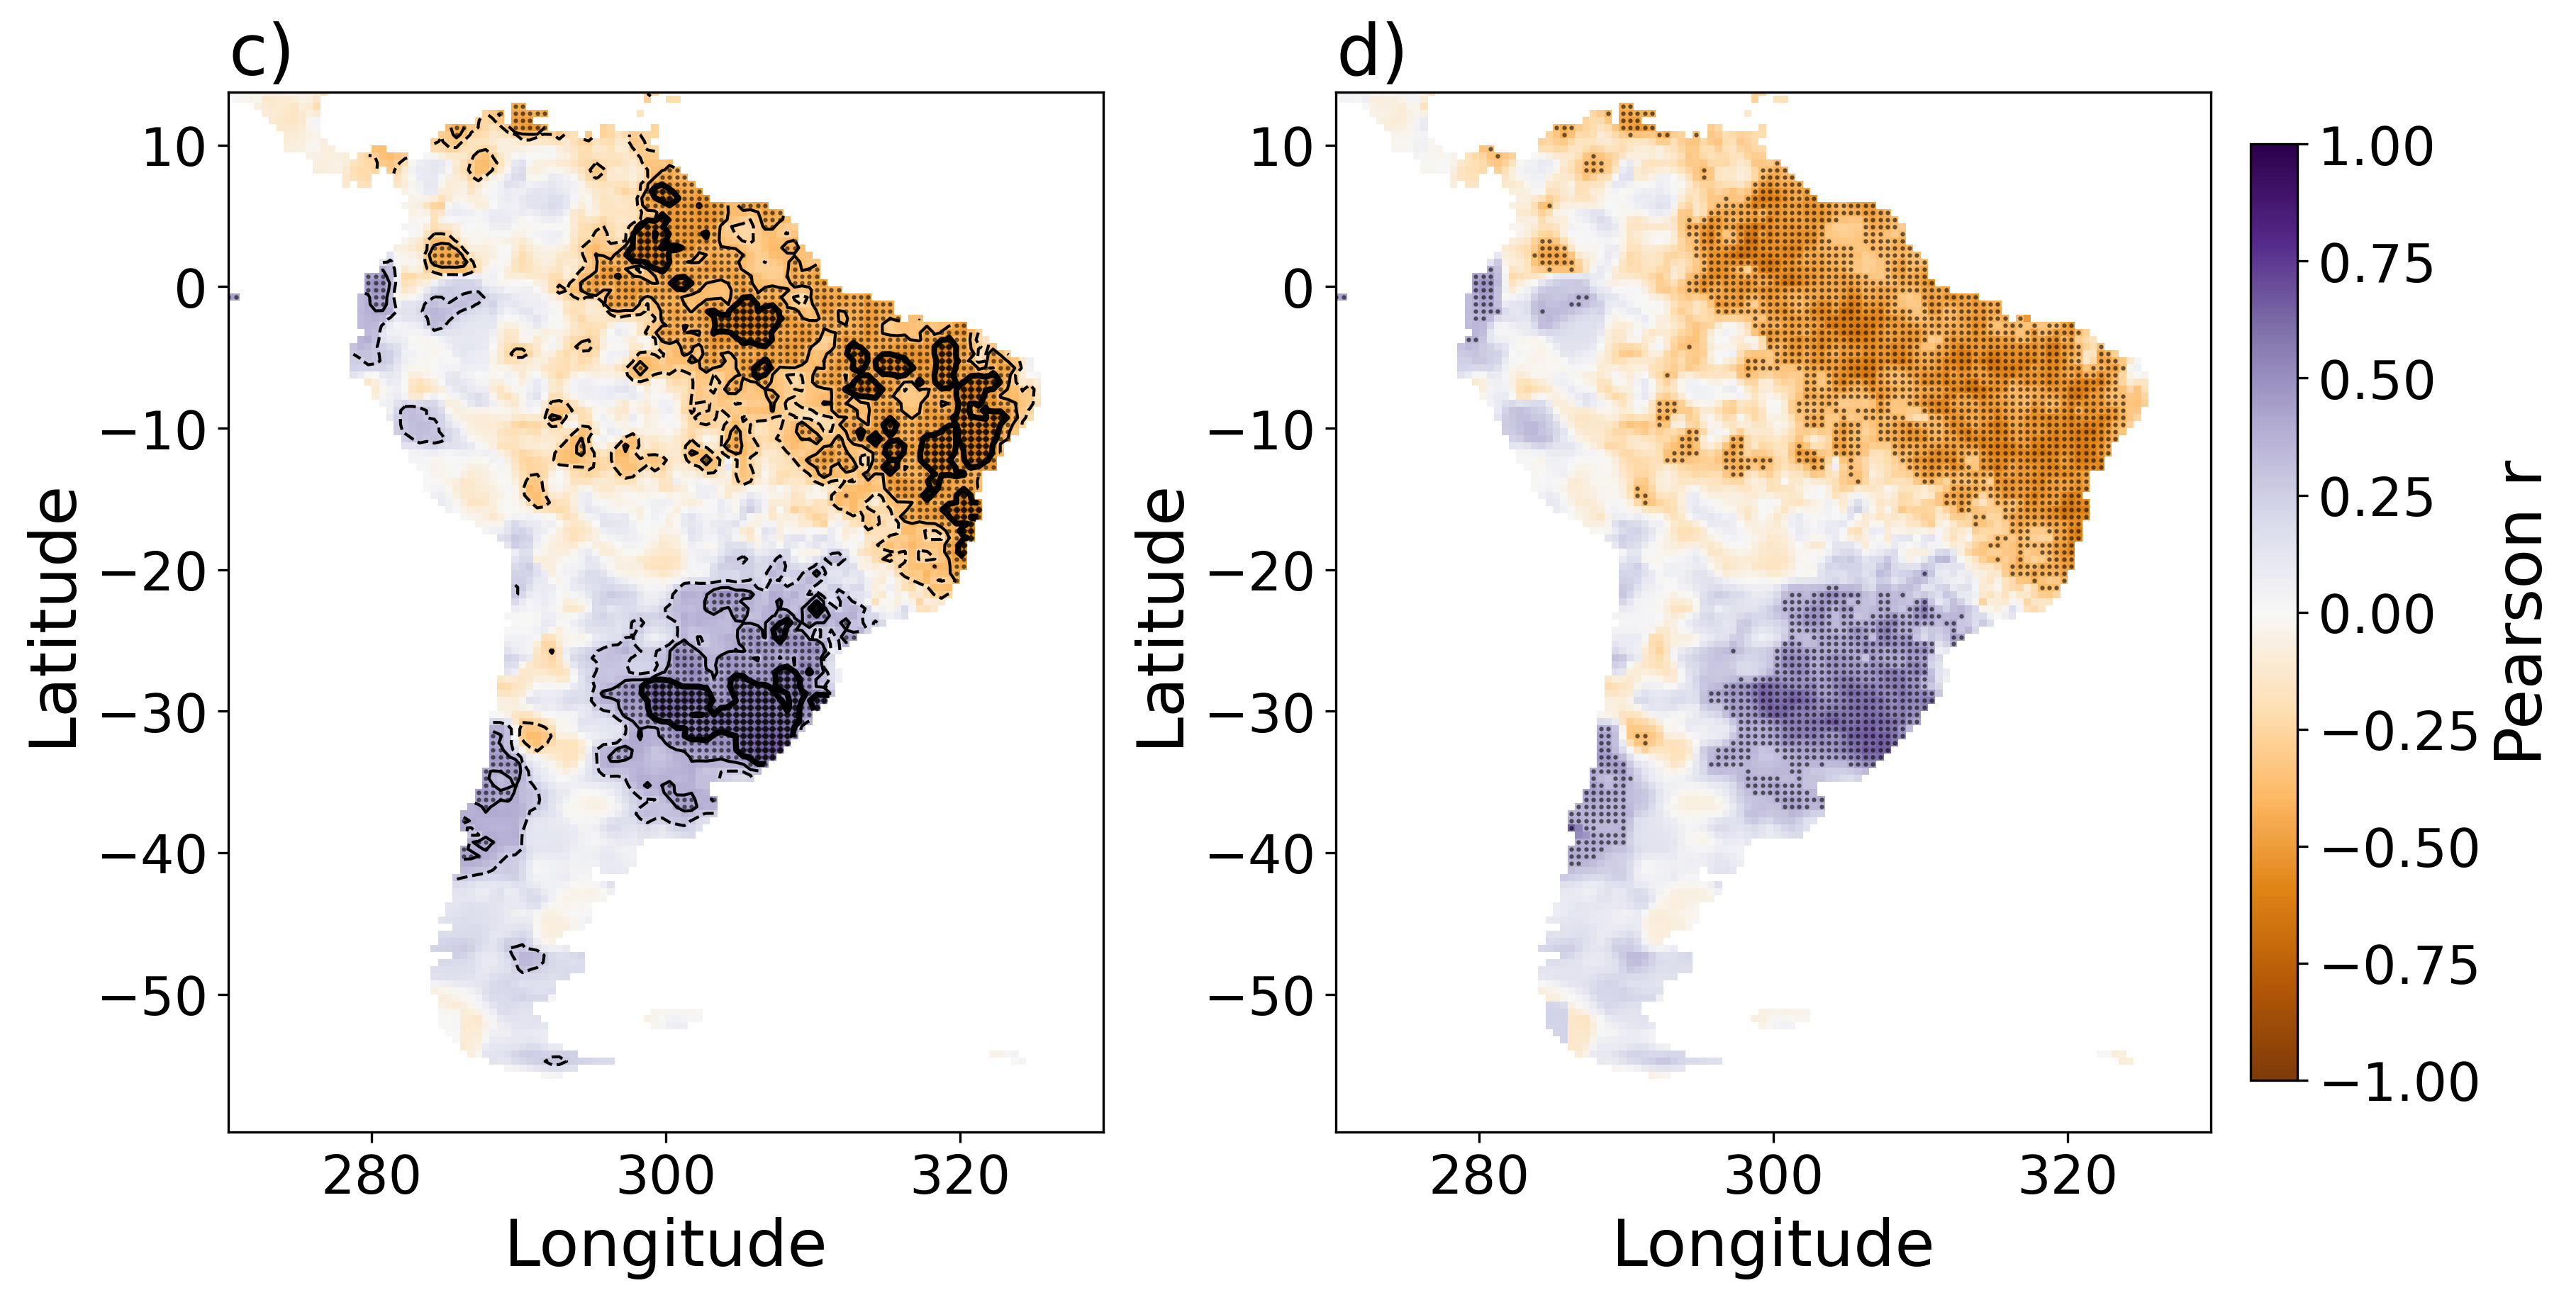

In [23]:
fig, axs = plt.subplots(
    1, 2,
    figsize=(12, 6),
    dpi=300,
    constrained_layout=True
)

# Rename for clarity (optional)
r = r_map_enso
bf = bf_map_enso
p = p_map_enso

# ============================
# (c) Correlation (r) map + BF contours + stippling
# ============================
im = axs[0].pcolormesh(
    r['lon'], r['lat'], r,
    cmap='PuOr', vmin=-1, vmax=1,
    shading='auto'
)
axs[0].set_title('c)', loc='left', fontsize=TITLE_FONTSIZE)

# ============================
# BF thresholds (UPDATED)
# ============================
bf_main = 3        # moderate evidence
bf_strong = 100    # strong evidence
bf_null = 1/3      # evidence for null

# Moderate evidence contour
cs_main = axs[0].contour(
    bf['lon'], bf['lat'], bf,
    levels=[bf_main],
    colors='k',
    linewidths=1
)

# Strong evidence contour
cs_strong = axs[0].contour(
    bf['lon'], bf['lat'], bf,
    levels=[bf_strong],
    colors='k',
    linewidths=2
)

# Evidence for null
cs_neg = axs[0].contour(
    bf['lon'], bf['lat'], bf,
    levels=[bf_null],
    colors='k',
    linewidths=1,
    linestyles='dashed'
)

# ============================
# Stippling
# ============================
lon2d, lat2d = np.meshgrid(r['lon'].values, r['lat'].values)

moderate = bf > bf_main
strong = bf > bf_strong

# Moderate evidence → dots
axs[0].scatter(
    lon2d[moderate], lat2d[moderate],
    s=1, color='k', marker='.', alpha=0.6
)

# Strong evidence → crosses
axs[0].scatter(
    lon2d[strong], lat2d[strong],
    s=2, color='k', marker='x', alpha=0.7
)

# ============================
# (d) Correlation map + classical stippling (p-values)
# ============================
# Apply FDR correction
sig_fdr, p_adj = fdr_bh_xarray(p_sa, alpha=0.05)

im2 = axs[1].pcolormesh(
    r_sa['lon'], r_sa['lat'], r_sa,
    cmap='PuOr', vmin=-1, vmax=1,
    shading='auto'
)
axs[1].set_title('d)', loc='left', fontsize=TITLE_FONTSIZE)

# Meshgrid for plotting
lon2d, lat2d = np.meshgrid(r_sa['lon'].values, r_sa['lat'].values)

# Stippling for FDR-significant points
axs[1].scatter(
    lon2d[sig_fdr.values],
    lat2d[sig_fdr.values],
    s=1, color='k', marker='.', alpha=0.6
)

# ============================
# Formatting
# ============================
for ax in axs:
    ax.set_xlim(r_sa['lon'].min(), r_sa['lon'].max())
    ax.set_ylim(r_sa['lat'].min(), r_sa['lat'].max())
    ax.set_xlabel('Longitude', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Latitude', fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    ax.set_aspect('auto')

# ============================
# Shared colorbar
# ============================
cbar = fig.colorbar(
    im,
    ax=axs,
    orientation='vertical',
    shrink=0.9,
    pad=0.02
)
cbar.set_label('Pearson r', fontsize=LABEL_FONTSIZE)
cbar.ax.tick_params(labelsize=TICK_FONTSIZE)

fig.savefig("panelCD_nEff_corrected.png", dpi=300)